In [1]:
import uuid
from typing import TypedDict, Optional, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from operator import add

In [2]:
class State(TypedDict):
    foo: int
    bar: Annotated[list[str], add]

In [3]:
def dummy_node(state: State):
    print("I m in dummy node")

In [4]:
builder = StateGraph(State)
builder.add_node("dummy", dummy_node)
builder.set_entry_point("dummy")
builder.add_edge("dummy", END)
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

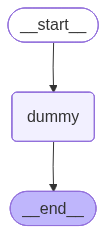

In [5]:
graph

In [6]:
config = {
    "configurable": {
        "thread_id": uuid.uuid4(),
    }
}

In [7]:
state = graph.invoke({"foo": 1, "bar": ["a"]}, config)

I m in dummy node


In [8]:
print(state)

{'foo': 1, 'bar': ['a']}


In [9]:
# The states are returned in reverse chronological order.
states = list(graph.get_state_history(config))

for state in states:
    print(state.next)
    print(state.config["configurable"]["checkpoint_id"])
    print("\n-----------------\n")

()
1f10a717-a7bd-6109-8001-24ffe1a2cec7

-----------------

('dummy',)
1f10a717-a7b8-6d7d-8000-9f925d94e5c4

-----------------

('__start__',)
1f10a717-a7b5-600f-bfff-7dce6794a870

-----------------



In [10]:
# This is the state before last (states are listed in chronological order)
selected_state = states[1]
print(selected_state.next)
print(selected_state.values)

('dummy',)
{'foo': 1, 'bar': ['a']}


In [14]:
new_config = graph.update_state(selected_state.config, values={"foo": 2, "bar": ["b"]})
# new_config = graph.update_state(selected_state.config, values={"foo": 2, "bar": ["b"]}, as_node = "__start__")
print(new_config)

{'configurable': {'thread_id': '9bffdaeb-2b17-4258-8685-72570aa05cef', 'checkpoint_ns': '', 'checkpoint_id': '1f10a74f-ac10-6af1-8001-23553060d1ae'}}


In [15]:
state = graph.invoke(None, new_config)

I m in dummy node


In [16]:
print(state)

{'foo': 2, 'bar': ['a', 'b']}
